In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from xgboost import XGBRegressor
import pickle

In [2]:
df = pd.read_csv('demand_forecasting.csv')
df["Category"].unique()


array(['Electronics', 'Clothing', 'Groceries', 'Toys', 'Furniture'],
      dtype=object)

In [3]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [4]:
features=["Price","Discount","Inventory Level","Promotion","Competitor Pricing","Category"]

In [5]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [6]:
target = "Demand"

In [7]:
x = df[features].copy()

In [8]:
y = df[target]
x


,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [9]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [10]:
x['Category'] = df['Category']

In [11]:
label_encoders = {}
categorical_cols = x.select_dtypes(include=['string','object']).columns


In [12]:
for col in categorical_cols:
    le = LabelEncoder()
    x[col]=le.fit_transform(x[col].astype(str))
    x[col] = x[col].astype(int)
    label_encoders[col] = le
    


In [13]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2)
print(x_train.dtypes)


Price                 float64
Discount                int64
Inventory Level         int64
Promotion               int64
Competitor Pricing    float64
Category                int64
dtype: object


In [14]:
xgb = XGBRegressor(objective="reg:squarederror",n_jobs=-1)

In [15]:
param_dict = {
    "n_estimators" : [200,300,500],
    "max_depth" : [3,4,6,8],
    "learning_rate" : [0.01, 0.05, 0.1],
    "subsample" : [0.7,0.8,1.0],
    "colsample_bytree" : [0.7,0.8,1.0],
    "min_child_weight" : [1,3,5]
    
    
}

In [16]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dict,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=1
)

In [ ]:
random_search.fit(x_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


In [ ]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 300,
 'min_child_weight': 1,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [ ]:
best_model = random_search.best_estimator_

In [ ]:
predicted = best_model.predict(x_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, predicted))

In [ ]:
best_model.feature_importances_

array([0.07953571, 0.02449217, 0.02626059, 0.57311153, 0.03088691,
       0.26571304], dtype=float32)

In [ ]:
feature_importance = pd.Series(best_model.feature_importances_,index=x.columns).sort_values(ascending=False)

In [ ]:
feature_importance

Promotion             0.573112
Category              0.265713
Price                 0.079536
Competitor Pricing    0.030887
Inventory Level       0.026261
Discount              0.024492
dtype: float32

<Axes: title={'center': 'Feature importance'}>

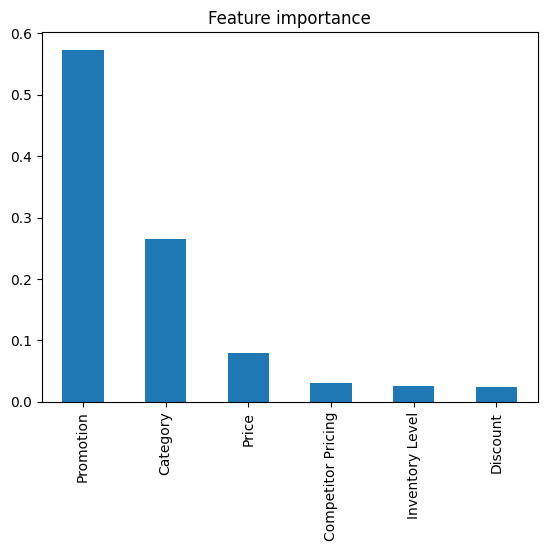

In [ ]:
feature_importance.plot(kind='bar',title="Feature importance")

In [ ]:
with open("label_encoders.pkl","wb") as f:
    pickle.dump(label_encoders,f)

In [ ]:
with open("xgboost_demand_model.pkl","wb") as f:
    pickle.dump(best_model,f)